# Load Libraries

In [ ]:
options(future.globals.maxSize = 1000000 * 1024^2)
set.seed(12345)

set.seed(1234)
# colors <- brewer.pal(12, "Set3")[-2]
# colors
# source('/sc/arion/work/kyriad02/ICH_project/workflow/scripts/utils.R')

# === Single-Cell Analysis Libraries ===
library(Seurat)               # Comprehensive toolkit for single-cell RNA-seq analysis
library(SingleCellExperiment) # Framework for storing and manipulating single-cell data
library(scCustomize)          # Customizations for Seurat single-cell workflows
library(muscat)               # Multi-sample, multi-group single-cell RNA-seq analysis tools
library(dreamlet)             # Tools for single-cell RNA-seq data and mixed models

# === Visualization Libraries ===
library(ComplexHeatmap)       # Advanced heatmap visualization
library(circlize)             # Circular visualization of genomic and other data
library(RColorBrewer)         # Provides color palettes for data visualization
library(ggplot2)              # General-purpose data visualization
library(ggtree)               # Phylogenetic tree visualization
library(cowplot)              # Plot composition and customization for ggplot2
library(patchwork)            # Arrange ggplot2 plots into custom layouts

# === Data Manipulation Libraries ===
library(dplyr)                # Data manipulation for data frames and tibbles
library(tidyr)                # Tools for tidying and reshaping data
library(readr)                # Read tabular data into R
library(tidyverse)            # A collection of R libraries for data science (dplyr, ggplot2, tidyr, etc.)
library(broom)                # Tidying model outputs into data frames for analysis

# === Statistical Analysis Libraries ===
library(variancePartition)    # Partitioning variance in complex experimental designs
library(metafor)              # Conduct meta-analysis using various statistical models
library(crumblr)              # Additional utilities for specific custom workflows

source('utils.R')

# Load Immune cells

In [4]:
Immune <- readRDS('2024_11_All_Immune.rds')

# Convert to SingleCellExperiment object

In [6]:
mat <- as.matrix(Immune@assays$RNA@counts)
dim(mat)
sce <- SingleCellExperiment(
  assays = list(counts = mat),
  colData = Immune@meta.data
)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 12.2 GiB”


[1] 17500 93378

# Aggregate To PseudoBulk the Celltypes

In [7]:
pbObj_Immune <- aggregateToPseudoBulk(sce,
    assay = "counts",
    cluster_id = "CellType",
    sample_id = "donor",
    BPPARAM = SnowParam(5, progressbar=TRUE))

# Run crumblR

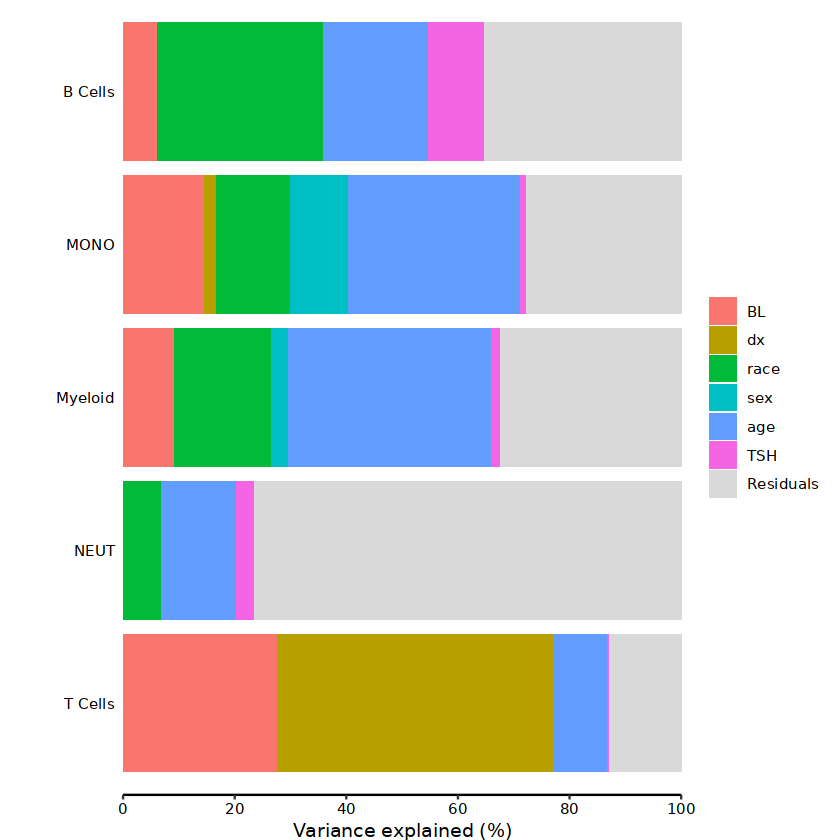

In [8]:
cobj = crumblr(cellCounts(pbObj_Immune))
# Partition variance into components for Subject (i.e. ind)
#   and stimulation status, and residual variation
vp = fitExtractVarPartModel( cobj, ~ (1|race) +(1|sex)+(1|BL)+(1|dx)+age+TSH, colData(pbObj_Immune))
# Plot variance fractions
plotPercentBars(vp)

In [9]:
# Build a hierarchical cluster tree from the pseudobulk object for immune cells
# This function likely organizes immune cell data into a hierarchical tree structure
hc = buildClusterTreeFromPB(pbObj_Immune)

# Define the model formula for linear mixed-effects modeling
# The formula includes random effects for race, sex, baseline level (BL), and diagnosis (dx),
# along with fixed effects for age and binned modified Rankin Scale (mRS_binned)
# The "+0" term removes the intercept, allowing for direct comparison between levels of mRS_binned
form = ~ (1 | race) + (1 | sex) + (1 | BL) + (1 | dx) + age + mRS_binned + 0

# Create contrast definitions for hypothesis testing
# The contrast here compares two levels of the mRS_binned variable: "B" and "G"
L = makeContrastsDream(form, colData(pbObj_Immune),
                       contrasts = c(mRS_contrast = "mRS_binnedB - mRS_binnedG"))

# Fit a mixed-effects model using the specified formula and contrasts
# The dream function fits the model while accounting for the specified random effects
fit = dream(cobj, form, colData(pbObj_Immune), L = L)

# Apply empirical Bayes moderation to the fitted model
# This step stabilizes the variance estimates and improves statistical power
fit = eBayes(fit)


In [10]:
# Convert the hierarchical cluster object (hc) into a phylogenetic tree object
# using the 'as.phylo' function from the ape package
fig.tree = dh_plotTree(ape::as.phylo(hc), 
                       xmax.scale = 2.5) +  # Plot the tree with an extended x-axis scale (2.5 times the default)
                
                # Customize the plot with additional theming
                theme(legend.position = "bottom",   # Position the legend at the bottom of the plot
                      text = element_text(size = 30)) +  # Set text size for plot elements to 30

                # Further customize the text size for the plot
                theme(text = element_text(size = 15))  # Override text size to 15 (applied last)



In [11]:
# Extract the top table of results for the specified contrast ("mRS_contrast")
# from the fitted model object (fit)
res.mRS = topTable(fit, coef = "mRS_contrast", 
                   number = Inf,   # Retrieve all results without limiting the number
                   sort.by = "none")  # Keep the original order of results without sorting

# Add a new column 'assay' to the results data frame
# This column is populated with the row names of 'res.mRS', typically representing assay or feature identifiers
res.mRS$assay <- rownames(res.mRS)

# Perform meta-analysis on the 'res.mRS' results
# Wrap the 'res.mRS' results in a list to make them compatible with the meta-analysis function
res.age = dh_meta_analysis(list(res.mRS))


In [12]:
# Generate a coefficient plot for the meta-analysis results (res.age)
# Specify the contrast of interest ('mRS'), link to the phylogenetic tree (fig.tree),
# and set the y-axis label to 'mRS'
fig.es1 <- dh_plotCoef(res.age, coef = 'mRS', fig.tree, ylab = 'mRS')

# Define color gradients for the plot
low = "grey90"   # Light color for low values
mid = "red"      # Intermediate color
high = "darkred" # Dark color for high values

# Set a scaling factor for the x-axis in tree visualization
xmax.scale = 3.5

# Test the phylogenetic tree structure using the specified model fit and contrast
# 'treeTest' evaluates how the hierarchical tree structure relates to the model
res = treeTest(fit, cobj, hc, coef = "mRS_binnedB")

# Create a ggtree visualization of the tree test results
fig = ggtree(res, branch.length = "none") +  # Visualize without branch length
        geom_tiplab(color = "black", size = 4, hjust = 0, offset = 0.2) +  # Add tip labels
        theme(legend.position = "top left",  # Position legend in the top-left corner
              plot.title = element_text(hjust = 0.5))  # Center the plot title

# Retrieve the default maximum value of the x-axis range from the tree plot
xmax = layer_scales(fig)$x$range$range[2]


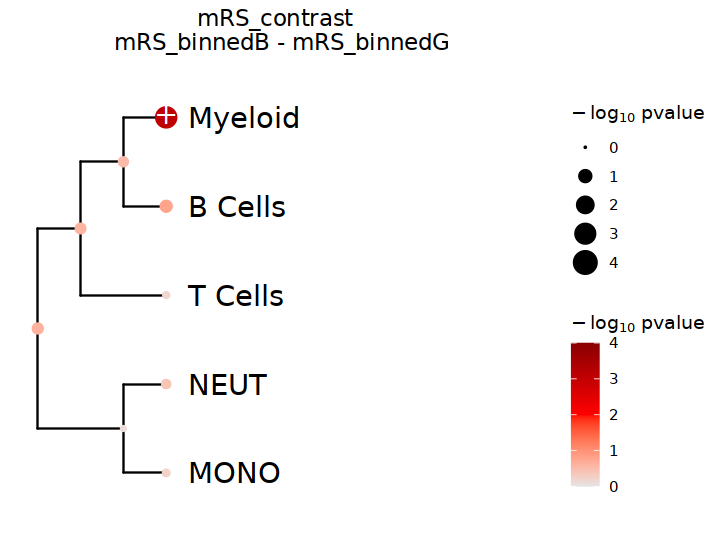

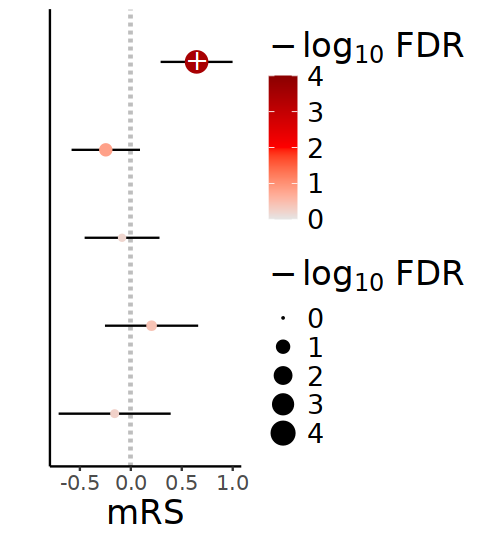

In [13]:
# Test the phylogenetic tree structure for association with the specified contrast ("mRS_contrast")
# using the fitted model (fit), pseudobulk data object (cobj), and hierarchical clustering (hc)
res = treeTest(fit, cobj, hc, coef = "mRS_contrast")

# Create a ggtree plot to visualize the tree test results
p <- ggtree(res, branch.length = "none") +  # Visualize the tree without branch lengths
    geom_tiplab(color = "black", size = 6, hjust = 0, offset = 0.5) +  # Add tip labels with styling
    geom_point2(aes(label = node, 
                    color = pmin(4, -log10(pvalue)),  # Set color based on p-value (capped at -log10(4))
                    size = pmin(5, -log10(pvalue)))) +  # Set point size based on p-value (capped at -log10(5))
    scale_color_gradient2(name = bquote(-log[10]~pvalue), 
                          limits = c(0, 4), low = low, mid = mid, high = high, midpoint = -log10(0.01)) +  # Define color gradient
    scale_size_area(name = bquote(-log[10]~pvalue), limits = c(0, 4)) +  # Define size scaling for points
    geom_text2(aes(label = '+', subset = pvalue < 0.05),  # Add "+" labels for significant nodes (p-value < 0.05)
               color = "white", size = 6, vjust = 0.3, hjust = 0.5) +
    theme(legend.position = "right",  # Position legend on the right
          plot.title = element_text(hjust = 0.5)) +  # Center-align the plot title
    xlim(0, xmax * xmax.scale) +  # Extend the x-axis range using the calculated xmax and scaling factor
    ggtitle("mRS_contrast \n mRS_binnedB - mRS_binnedG")  # Add plot title

# Optionally save the plot to a PDF file (uncomment the lines below to enable)
pdf('Figure1_E1.pdf', width = 6, height = 4.5)
p  # Print the plot to the PDF
dev.off()  # Close the PDF device

# Optionally save another plot (fig.es1) to a separate PDF (uncomment the lines below to enable)
pdf('Figure1_E2.pdf', width = 4, height = 4.5)
options(repr.plot.width = 4, repr.plot.height = 4.5)  # Adjust plot size for output
fig.es1  # Print the plot to the PDF
dev.off()  # Close the PDF device

# Set plotting dimensions for in-session viewing of the ggtree plot
options(repr.plot.width = 6, repr.plot.height = 4.5)
p  # Display the ggtree plot

# Set plotting dimensions for in-session viewing of the coefficient plot (fig.es1)
options(repr.plot.width = 4, repr.plot.height = 4.5)
fig.es1  # Display the coefficient plot


# SessionInfo

In [14]:
sessionInfo()

R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 9.4 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] grid      stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] lubridate_1.9.2             forcats_1.0.0              
 [3] stringr_1.5.0               purrr_1.0.1                
 [5] tibble_3.2.1                tidyverse_2.0.0  